# Week 1 · Go Nuts — the Marvel Wikipedia link network

**The dataset.** 303 characters from Wikipedia's *Category:Marvel Comics
superheroes*, plus the 1&nbsp;784 directed links between their articles
(`A → B` when article *A* links to article *B*). Frozen course snapshot,
2026-08-26, so every group computes on identical data.

**What I asked**

1. What shape is the degree distribution — linear and log–log — and is it heavy-tailed?
2. In-degree vs out-degree: the most-linked-**to** character and the most-linking-**out**
   character are different people. Why?
3. The data page warns about *isolated* nodes. Are they the **only** thing outside the
   giant component?

**Main findings** — Spider-Man has 106 inbound links; Betsy Braddock leads
outbound links with 28. There are 17 isolates and a separate nine-node island.
Degree counts describe article references. They do not directly measure fame
or narrative complexity, and these plots do not establish a power law.

In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms.community import louvain_communities

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})
DATA = Path("../../../data/week1")

## Load it so the isolates survive

The data page is explicit: build the graph from the **node list first**, then add
edges. 17 characters have no link in either direction — start from the edge list
alone and you silently drop them.

In [2]:
def read_rows(path):
    """Yield TSV rows, skipping the `#` comment header block."""
    with open(path, encoding="utf-8") as fh:
        yield from csv.reader(
            (ln for ln in fh if not ln.startswith("#")), delimiter="\t"
        )


node_rows = list(read_rows(DATA / "week1_nodes.tsv"))
header = node_rows[0]
meta = {r[0]: dict(zip(header, r)) for r in node_rows[1:]}
name = {k: v["name"] for k, v in meta.items()}

# the "# source  target" line is a comment, so every remaining row is an edge
edges = [(a, b) for a, b in read_rows(DATA / "week1_edges.tsv") if a != "source"]

G = nx.DiGraph()
G.add_nodes_from(meta)            # all 303, isolates included
G.add_edges_from(edges)          # 1784 directed links
nx.set_node_attributes(G, name, "name")

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
assert (G.number_of_nodes(), G.number_of_edges()) == (303, 1784)

303 nodes, 1784 edges


In [3]:
ind = dict(G.in_degree())
outd = dict(G.out_degree())
deg = dict(G.degree())

overview = pd.Series(
    {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "mean total degree": round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
        "density": round(nx.density(G), 4),
        "reciprocity": round(nx.reciprocity(G), 3),
        "isolates": len(list(nx.isolates(G))),
        "max in-degree": max(ind.values()),
        "max out-degree": max(outd.values()),
    },
    name="value",
)
overview.to_frame()

,value
nodes,303.0000
edges,1784.0000
mean total degree,11.7800
density,0.0195
reciprocity,0.3920
isolates,17.0000
max in-degree,106.0000
max out-degree,28.0000


## Q1 · Degree distributions

Left: **linear** histogram of total degree — a steep right skew, most characters
under 20, and one bar out on its own near 115. Middle: the same on **log–log**
axes, in- and out-degree separately — both right-skewed, but the
in-degree tail runs three times further. Right: the **CCDF**, which is the
fraction of articles at or above each positive degree.

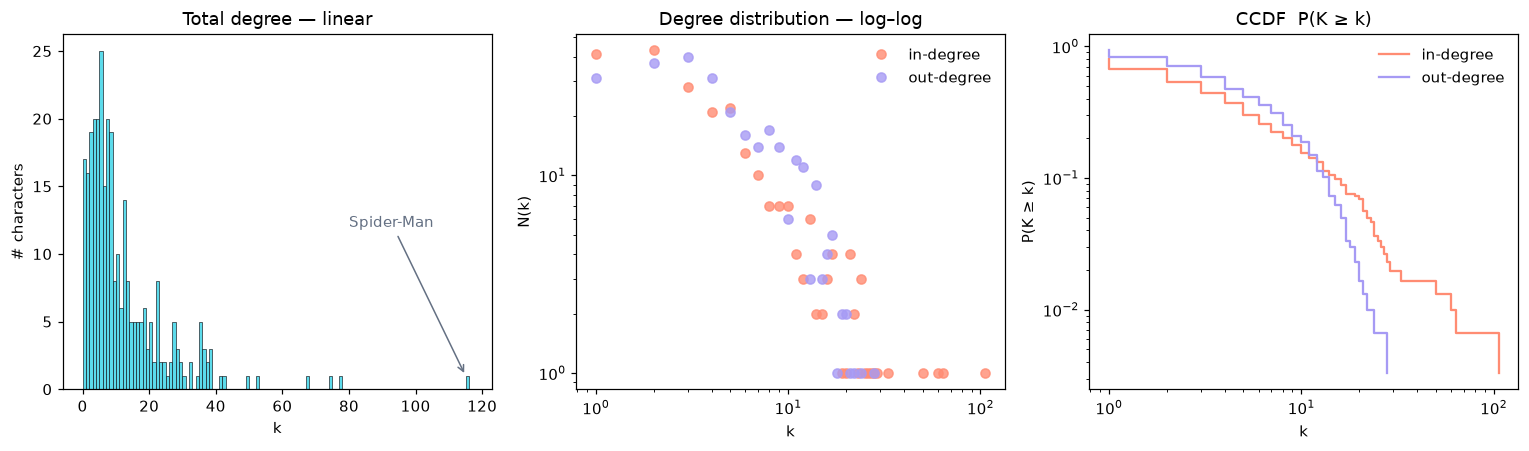

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

tot = np.array([deg[n] for n in G])
ax[0].hist(tot, bins=range(0, tot.max() + 3), color="#5cdbeb", edgecolor="#0c0d12", lw=0.4)
ax[0].set(title="Total degree — linear", xlabel="k", ylabel="# characters")
ax[0].annotate("Spider-Man", xy=(115, 1), xytext=(80, 12),
               arrowprops=dict(arrowstyle="->", color="#647083"), color="#647083")

for seq, lab, col in [(ind, "in-degree", "#ff8c73"), (outd, "out-degree", "#a69af4")]:
    c = Counter(seq.values())
    ks = np.array(sorted(k for k in c if k > 0))
    ax[1].loglog(ks, [c[k] for k in ks], "o", ms=6, color=col, label=lab, alpha=.8)
ax[1].set(title="Degree distribution — log–log", xlabel="k", ylabel="N(k)")
ax[1].legend(frameon=False)

for seq, lab, col in [(ind, "in-degree", "#ff8c73"), (outd, "out-degree", "#a69af4")]:
    v = np.sort(np.array(list(seq.values())))
    ccdf = 1 - np.arange(len(v)) / len(v)
    ax[2].loglog(v[v > 0], ccdf[v > 0], drawstyle="steps-post", color=col, label=lab)
ax[2].set(title="CCDF  P(K ≥ k)", xlabel="k", ylabel="P(K ≥ k)")
ax[2].legend(frameon=False)

fig.tight_layout()
Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/degree-distributions.png", dpi=130, bbox_inches="tight")
plt.show()

## Q2 · In-degree ≠ out-degree — and why

The two leaderboards barely overlap.

In [5]:
def leaderboard(scores, other, k=10):
    top = sorted(scores, key=scores.get, reverse=True)[:k]
    return pd.DataFrame(
        {"character": [name[n] for n in top],
         "this": [scores[n] for n in top],
         "other": [other[n] for n in top]}
    )


most_linked_to = leaderboard(ind, outd).rename(columns={"this": "in", "other": "out"})
most_linking_out = leaderboard(outd, ind).rename(columns={"this": "out", "other": "in"})
pd.concat({"most linked TO": most_linked_to,
           "most linking OUT": most_linking_out}, axis=1)

most linked TO                        most linking OUT        
                   character   in out                      character out  in
0                 Spider-Man  106   9                 Betsy Braddock  28   7
1                       Hulk   64  10  Cloak and Dagger (characters)  24  11
2      Wolverine (character)   60  17                   Adam Warlock  22   8
3             Doctor Strange   50  17              Venom (character)  21  17
4                   Deadpool   33  19                       She-Hulk  20  29
5                   She-Hulk   29  20                     U.S. Agent  20   6
6              Scarlet Witch   28  14                       Deadpool  19  33
7  Black Panther (character)   27  11                 Rachel Summers  19  16
8    Cyclops (Marvel Comics)   26  11                       Noh-Varr  18   4
9                  Luke Cage   25   9                 Doctor Strange  17  50

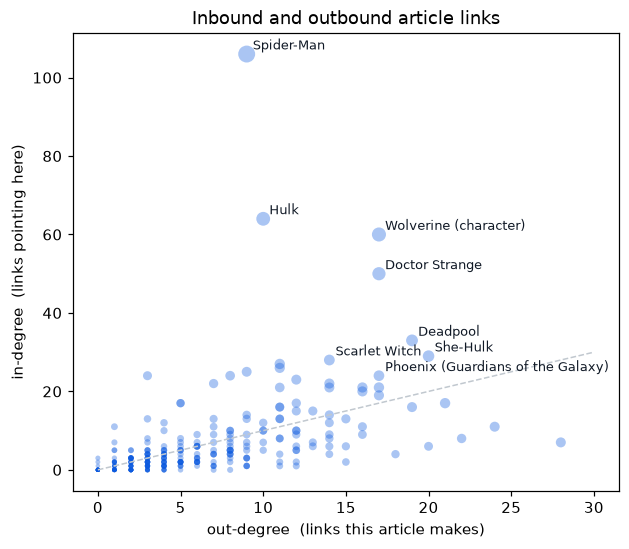

In [6]:
# in vs out per node — compare inbound and outbound article references
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter([outd[n] for n in G], [ind[n] for n in G],
           s=[8 + deg[n] for n in G], c="#0c5adf", alpha=.35, edgecolors="none")
for n in sorted(G, key=lambda n: ind[n] + outd[n], reverse=True)[:8]:
    ax.annotate(name[n], (outd[n], ind[n]), fontsize=8.5, color="#101926",
                xytext=(4, 3), textcoords="offset points")
ax.plot([0, 30], [0, 30], "--", color="#c1c8cf", lw=1)
ax.set(xlabel="out-degree  (links this article makes)",
       ylabel="in-degree  (links pointing here)",
       title="Inbound and outbound article links")
plt.show()

**Two different roles.** Spider-Man has 106 inbound / 9 outbound links;
Betsy Braddock has 7 inbound / 28 outbound. Recognition, article length and
editorial choices are possible explanations, not quantities tested here.
Reciprocity is 0.392: roughly 39% of directed edges have a reverse edge.

## Q3 · What is outside the giant component?

Weakly-connected components (treat every link as undirected, ask "is there any path"):

In [7]:
wcc = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
giant = wcc[0]
comp_summary = pd.Series(Counter(len(c) for c in wcc)).sort_index()
comp_summary.index.name = "component size"
comp_summary.rename("count").to_frame()

,count
component size,
1,17
9,1
277,1


In [8]:
island = next(c for c in wcc if 1 < len(c) < len(giant))
isolates = [n for n in G if deg[n] == 0]

print("Giant component:", len(giant), "nodes")
print(f"\nThe 9-node ISLAND (no path to the giant, in either direction):")
for n in sorted(island, key=lambda n: name[n]):
    print("  ", name[n])
print(f"\nThe {len(isolates)} ISOLATES (degree 0):")
for n in sorted(isolates, key=lambda n: name[n]):
    print("  ", name[n])

Giant component: 277 nodes

The 9-node ISLAND (no path to the giant, in either direction):
   Backhand (character)
   Blackthorn (character)
   Radian (Morituri)
   Scaredycat
   Scatterbrain (Morituri)
   Shear (character)
   Snapdragon (Morituri)
   Toxyn
   Vyking

The 17 ISOLATES (degree 0):
   Baymax
   Bird-Brain (Marvel Comics)
   Black Fox (Robert Paine)
   Brain Drain (character)
   Breeze Barton
   Captain Midlands
   Charcoal (comics)
   Father Time (Marvel Comics)
   Happy Sam Sawyer
   Hellfire (J. T. Slade)
   Illuminator (Marvel Comics)
   Miracleman (character)
   Ogre (Marvel Comics)
   Sean and Chris
   Solarman
   Super Rabbit
   Yo-Yo Rodriguez


### The surprise

The giant component holds **277** of the 286 non-isolated nodes. The other **9 form a
fully separate island** — and they are not random:

> Backhand · Blackthorn · Radian · Scaredycat · Scatterbrain · Shear · Snapdragon · Toxyn · Vyking

— nine articles, three of whose titles explicitly carry the *Morituri* label.
They have no links to the giant within this sample. Paths via articles outside
the roster may still exist. Loading edges alone drops the 17 isolates but
preserves this nine-node island.

## Bonus 1 · Communities — the link graph knows the Marvel "families"

Louvain on the (undirected) giant component finds 8 groups. Labelling each by its
highest-degree members, the labels are interpretations, not verified franchise classifications.

In [9]:
U = G.subgraph(giant).to_undirected()
comms = sorted(louvain_communities(U, seed=42), key=len, reverse=True)
comm_id = {n: i for i, c in enumerate(comms) for n in c}

LABELS = {
    0: "X-Men",
    1: "Cosmic / Guardians",
    2: "Hulk & Avengers-adjacent",
    3: "Spider-family",
    4: "Street-level / espionage",
    5: "Supernatural / Midnight Sons",
    6: "Classic Avengers / synthezoids",
    7: "Heroes for Hire / Defenders",
}
rows = []
for i, c in enumerate(comms):
    top = sorted(c, key=deg.get, reverse=True)[:5]
    rows.append({"#": i, "label": LABELS.get(i, "?"), "size": len(c),
                 "top members": ", ".join(name[n] for n in top)})
pd.DataFrame(rows).set_index("#")

,label,size,top members
#,,,
0,X-Men,43,"Wolverine (character), Phoenix (Guardians of t..."
1,Cosmic / Guardians,41,"Hercules (Marvel Comics), Adam Warlock, Quasar..."
2,Hulk & Avengers-adjacent,38,"Hulk, She-Hulk, Hank Pym, Robbie Baldwin, Pats..."
3,Spider-family,37,"Spider-Man, Venom (character), Black Cat (Marv..."
4,Street-level / espionage,34,"Moon Knight, Cloak and Dagger (characters), Bl..."
5,Supernatural / Midnight Sons,31,"Doctor Strange, Deadpool, Blade (character), G..."
6,Classic Avengers / synthezoids,31,"Scarlet Witch, Human Torch (android), Black Bo..."
7,Heroes for Hire / Defenders,22,"Black Panther (character), Iron Fist (characte..."


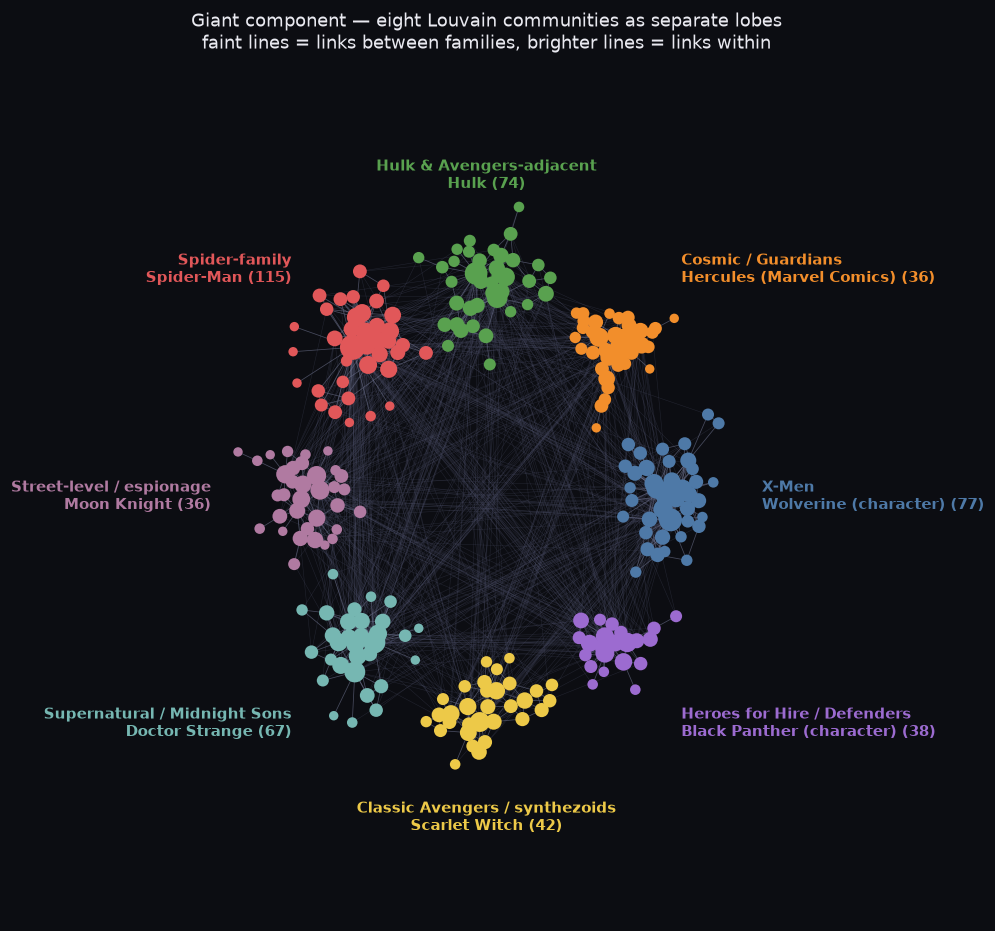

In [10]:
# improved network drawing: each community laid out on its own, then the eight
# clusters placed around a ring so the families read as distinct lobes.
pal = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#b07aa1",
       "#76b7b2", "#edc948", "#9c6bd0"]


def community_layout(U, comms):
    biggest = max(len(c) for c in comms)
    pos = {}
    for i, c in enumerate(comms):
        local = nx.spring_layout(U.subgraph(c), k=0.55, iterations=200, seed=1)
        ang = 2 * np.pi * i / len(comms)
        centre = 3.1 * np.array([np.cos(ang), np.sin(ang)])
        span = 0.65 + 0.55 * np.sqrt(len(c) / biggest)
        for n, p in local.items():
            pos[n] = centre + span * np.array(p)
    return pos


pos = community_layout(U, comms)
intra = [(a, b) for a, b in U.edges() if comm_id[a] == comm_id[b]]
inter = [(a, b) for a, b in U.edges() if comm_id[a] != comm_id[b]]

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor("#0c0d12"); ax.set_facecolor("#0c0d12")
nx.draw_networkx_edges(U, pos, edgelist=inter, ax=ax, edge_color="#4a4d66", width=.35, alpha=.35)
nx.draw_networkx_edges(U, pos, edgelist=intra, ax=ax, edge_color="#6f7490", width=.5, alpha=.6)
nx.draw_networkx_nodes(
    U, pos, ax=ax, node_size=[14 + 24 * np.sqrt(deg[n]) for n in U],
    node_color=[pal[comm_id[n]] for n in U], linewidths=0,
)
for i, c in enumerate(comms):
    hub = max(c, key=deg.get)
    ang = 2 * np.pi * i / len(comms)
    lp = 4.7 * np.array([np.cos(ang), np.sin(ang)])
    ha = "center" if abs(np.cos(ang)) < 0.3 else ("left" if np.cos(ang) > 0 else "right")
    ax.annotate(f"{LABELS[i]}\n{name[hub]} ({deg[hub]})", lp, color=pal[i],
                fontsize=9.5, fontweight="bold", ha=ha, va="center")
ax.set_title("Giant component — eight Louvain communities as separate lobes\n"
             "faint lines = links between families, brighter lines = links within",
             color="#e9e9f0", pad=16)
ax.set_xlim(-8, 8); ax.set_ylim(-6.2, 6.2)
ax.axis("off")
Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/communities.png", dpi=130, facecolor="#0c0d12", bbox_inches="tight")
plt.show()

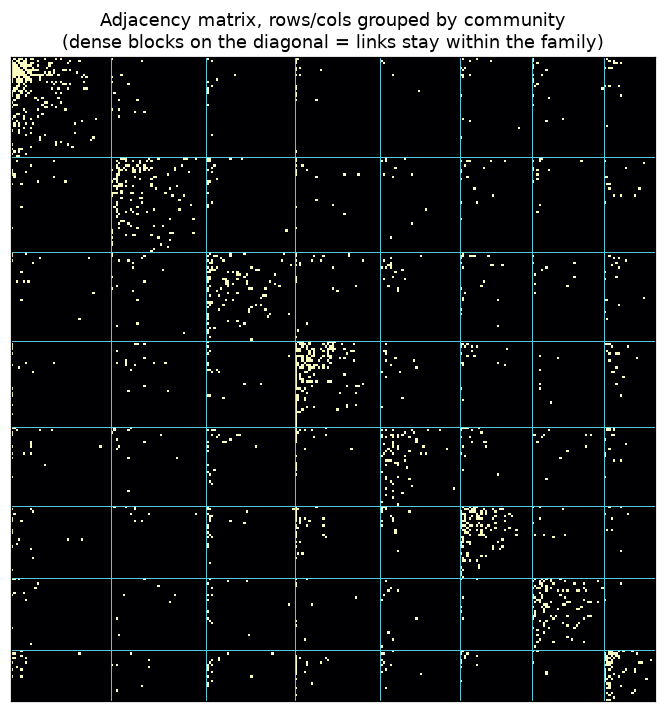

In [11]:
# the same structure, stated crisply: adjacency matrix reordered by community
order = [n for i in range(len(comms)) for n in sorted(comms[i], key=deg.get, reverse=True)]
idx = {n: i for i, n in enumerate(order)}
M = np.zeros((len(order), len(order)))
for a, b in G.subgraph(giant).edges():
    M[idx[a], idx[b]] = 1

fig, ax = plt.subplots(figsize=(7.6, 7.6))
ax.imshow(M, cmap="magma", interpolation="nearest")
b = 0
for c in comms:
    b += len(c)
    ax.axhline(b - .5, color="#5cdbeb", lw=.6)
    ax.axvline(b - .5, color="#5cdbeb", lw=.6)
ax.set_title("Adjacency matrix, rows/cols grouped by community\n"
             "(dense blocks on the diagonal = links stay within the family)")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## The surprise: the X-Men are a walled garden

The community Louvain locks onto most cleanly (Wolverine's, 43 nodes) is also
the one that barely links out. Below: the share of each community's links that
stay *inside* it. The street-level and Heroes-for-Hire groups only ~a quarter;
the X-Men more than half. The algorithm finds them so easily *because* they are
a closed clique — which matches decades of editorially walled-off X-Men books.

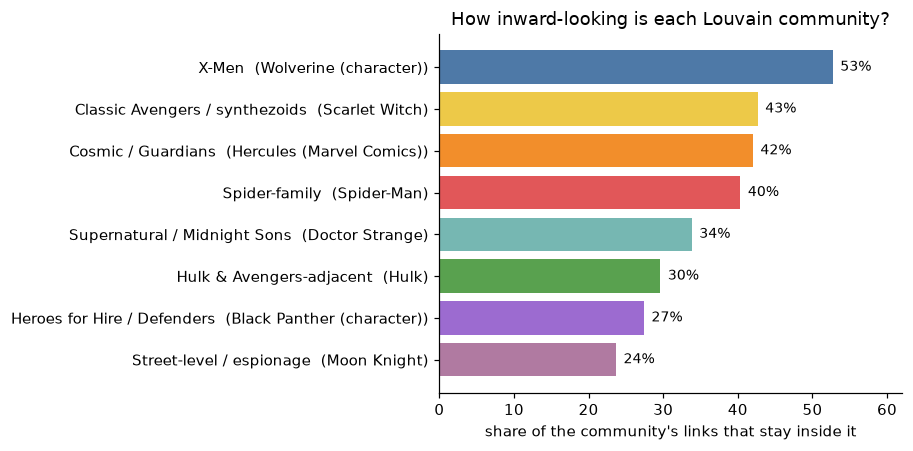

X-Men  (Wolverine (character))             53% internal
Classic Avengers / synthezoids  (Scarlet Witch)   43% internal
Cosmic / Guardians  (Hercules (Marvel Comics))   42% internal
Spider-family  (Spider-Man)                40% internal
Supernatural / Midnight Sons  (Doctor Strange)   34% internal
Hulk & Avengers-adjacent  (Hulk)           30% internal
Heroes for Hire / Defenders  (Black Panther (character))   27% internal
Street-level / espionage  (Moon Knight)    24% internal


In [12]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
gedges = list(G.subgraph(giant).edges())
bars = []
for i, c in enumerate(comms):
    cs = set(c)
    inside = sum(1 for a, b in gedges if a in cs and b in cs)
    touching = sum(1 for a, b in gedges if a in cs or b in cs)
    bars.append((f"{LABELS[i]}  ({name[max(c, key=deg.get)]})",
                 100 * inside / touching, pal[i]))
bars.sort(key=lambda r: r[1])
ax.barh([b[0] for b in bars], [b[1] for b in bars],
        color=[b[2] for b in bars], edgecolor="none")
for y, (_, v, _) in enumerate(bars):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 62)
ax.set_xlabel("share of the community's links that stay inside it")
ax.set_title("How inward-looking is each Louvain community?")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("assets/insularity.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n".join(f"{n:40} {v:4.0f}% internal" for n, v, _ in reversed(bars)))

## Bonus 2 · PageRank vs in-degree — who is *more* central than their link count says

PageRank rewards being linked from *important* pages, not just many pages. The
biggest climbers vs raw in-degree are all in the Spider-family: they get their
rank from Spider-Man pointing at them.

In [13]:
pr = nx.pagerank(G)
rank_pr = {n: i for i, n in enumerate(sorted(G, key=pr.get, reverse=True))}
rank_in = {n: i for i, n in enumerate(sorted(G, key=ind.get, reverse=True))}
climb = sorted(G, key=lambda n: rank_in[n] - rank_pr[n], reverse=True)[:10]
pd.DataFrame({
    "character": [name[n] for n in climb],
    "PageRank rank": [rank_pr[n] + 1 for n in climb],
    "in-degree rank": [rank_in[n] + 1 for n in climb],
    "in-degree": [ind[n] for n in climb],
})

,character,PageRank rank,in-degree rank,in-degree
0,Spider-UK,43,195,2
1,Marvel Boy (Robert Grayson),59,185,2
2,Devil Hulk,103,216,1
3,Scatterbrain (Morituri),88,191,2
4,She-Hulk (Lyra),89,192,2
5,Snapdragon (Morituri),90,193,2
6,Vyking,57,160,3
7,Toxyn,75,158,3
8,Scaredycat,69,151,3
9,Yelena Belova,126,204,2


## Bonus 3 · Degrees of separation

Small helper — the shortest directed path of Wikipedia links between any two
characters.

In [14]:
def path_between(a, b):
    sa = next(k for k, v in name.items() if v.lower() == a.lower())
    sb = next(k for k, v in name.items() if v.lower() == b.lower())
    p = nx.shortest_path(G, sa, sb)
    return " → ".join(name[n] for n in p)


print(path_between("Squirrel Girl", "Galactus") if False else "")
for pair in [("Deadpool", "Storm (Marvel Comics)"), ("Kamala Khan", "Namor"),
             ("Groot", "Daredevil")]:
    try:
        print(f"{pair[0]:24} →  {path_between(*pair)}")
    except (StopIteration, nx.NetworkXNoPath) as e:
        print(f"{pair[0]} → {pair[1]}: no path ({e})")


Deadpool                 →  Deadpool → Gwenpool → Storm (Marvel Comics)
Kamala Khan → Namor: no path ()
Groot → Daredevil: no path ()


## Interactive explorer

The polished interactive version is a standalone D3 page — `explorer.html` in
this folder. Hover a character to light up who it links to (yellow) and who
links to it (cyan); switch the colouring between **community**, **component**
and an **in-degree heat map**; filter by minimum degree; search; drag; zoom;
double-click a node to open its Wikipedia article. It reads `data/graph.json`,
which the next cell (re)writes with the community assignment computed above.

In [15]:
# write graph.json (positions + degree + community) for explorer.html
import json  # noqa: E402

ids = list(G)
node_idx = {n: i for i, n in enumerate(ids)}
gj_nodes = [
    {"id": n, "name": name[n],
     "x": round(float(pos[n][0]), 3) if n in pos else None,
     "y": round(float(pos[n][1]), 3) if n in pos else None,
     "in": ind[n], "out": outd[n], "deg": deg[n],
     "grp": "isolate" if deg[n] == 0 else ("giant" if n in giant else "island"),
     "comm": comm_id.get(n, -1),
     "commLabel": LABELS.get(comm_id.get(n, -1), "")}
    for n in ids
]
# island + isolate placeholder coords (giant already has community_layout coords)
for i, n in enumerate(sorted(island, key=name.get)):
    gj_nodes[node_idx[n]]["x"] = -11.0 + 1.4 * np.cos(2 * np.pi * i / len(island))
    gj_nodes[node_idx[n]]["y"] = 1.4 * np.sin(2 * np.pi * i / len(island))
for i, n in enumerate(sorted(isolates, key=name.get)):
    gj_nodes[node_idx[n]]["x"] = -13.0
    gj_nodes[node_idx[n]]["y"] = 6.0 - 12.0 * i / (len(isolates) - 1)

gj = {"nodes": gj_nodes,
      "links": [{"s": node_idx[a], "t": node_idx[b]} for a, b in G.edges()],
      "communities": [{"id": i, "label": LABELS[i], "color": pal[i]} for i in range(len(comms))]}
Path("../../../data/graph.json").write_text(json.dumps(gj, separators=(",", ":")) + "\n")

summary = {
    "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges(),
    "mean_degree": round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
    "density": round(nx.density(G), 4), "reciprocity": round(nx.reciprocity(G), 3),
    "giant_size": len(giant), "n_isolates": len(isolates),
    "island_size": len(island), "n_communities": len(comms),
    "top_in": [[name[n], ind[n], outd[n]] for n in sorted(ind, key=ind.get, reverse=True)[:10]],
    "top_out": [[name[n], outd[n], ind[n]] for n in sorted(outd, key=outd.get, reverse=True)[:10]],
    "island_members": sorted(name[n] for n in island),
    "isolates": sorted(name[n] for n in isolates),
    "communities": [{"label": LABELS[i], "size": len(c),
                     "top": [name[n] for n in sorted(c, key=deg.get, reverse=True)[:5]]}
                    for i, c in enumerate(comms)],
}
Path("summary.json").write_text(json.dumps(summary, indent=2) + "\n")
print(f"wrote data/graph.json ({len(gj_nodes)} nodes, {len(gj['links'])} links) "
      f"and summary.json")

wrote data/graph.json (303 nodes, 1784 links) and summary.json


In [16]:
from IPython.display import IFrame  # noqa: E402

IFrame("explorer.html", width="100%", height=660)

## Stretch · does the frozen snapshot match live Wikipedia?

Pull the current wiki-source from the API (`action=parse&prop=wikitext`, with a
`User-Agent` identifying the client), scrape the `[[links]]`, keep those pointing at another
of the 303, and diff against the snapshot's out-edges.

In [17]:
import re  # noqa: E402
import time  # noqa: E402
import urllib.parse  # noqa: E402
import urllib.request  # noqa: E402
import json as _json  # noqa: E402

API = "https://en.wikipedia.org/w/api.php"
UA = "socialgraphs2026-gonuts/1.0 (course exercise)"
LINK = re.compile(r"\[\[\s*([^\]|#<>{}]+?)\s*(?:\|[^\]]*)?\]\]")
ID_BY_NAME = {v: k for k, v in name.items()}
IDS = set(G)
snap_out = {a: set() for a in G}
for a, b in G.edges():
    snap_out[a].add(b)


def live_wikitext(title):
    q = urllib.parse.urlencode({"action": "parse", "page": title, "prop": "wikitext",
                                "redirects": 1, "format": "json", "formatversion": 2})
    req = urllib.request.Request(f"{API}?{q}", headers={"User-Agent": UA})
    with urllib.request.urlopen(req, timeout=30) as r:
        return _json.load(r)["parse"]["wikitext"]


def norm(link):
    t = link.strip().replace(" ", "_")
    return t[:1].upper() + t[1:]


rows = []
for cname in ["She-Hulk", "Adam Warlock", "Doctor Strange", "Venom (character)", "Luke Cage"]:
    nid = ID_BY_NAME[cname]
    live = {norm(m) for m in LINK.findall(live_wikitext(nid.replace("_", " ")))} & IDS
    snap = snap_out[nid]
    rows.append({"character": cname, "snapshot": len(snap), "live wikitext": len(live),
                 "shared": len(snap & live), "snapshot-only": len(snap - live),
                 "live-only": len(live - snap)})
    time.sleep(1)
pd.DataFrame(rows).set_index("character")

,snapshot,live wikitext,shared,snapshot-only,live-only
character,,,,,
She-Hulk,20,17,16,4,1
Adam Warlock,22,21,21,1,0
Doctor Strange,17,15,15,2,0
Venom (character),21,19,19,2,0
Luke Cage,9,7,7,2,0


**The stored run recovered 82/89 snapshot links (92%)** across five articles,
with seven snapshot-only links and no live-only links detected by this parser.
Revision IDs and retrieval time were not saved. Parsing, title/redirect handling
and page edits could explain the mismatch; its cause has not been established.
This spot-check does not validate the entire snapshot.

## What surprised me

1. The nine-node island remains separate even when direction is ignored.
2. Louvain finds eight communities with recognisable prominent members, though
   the labels are interpretations and the separated lobes are imposed by layout.
3. The saved API spot-check recovers 82/89 links; the seven misses remain unexplained.
